# City of Los Angeles Civil Service — Data Visualizations

**Thesis:** Credential barriers and internal mobility structures in the City of Los Angeles civil service system create differential pathways to public sector employment and compensation, with formal education requirements not consistently predicting higher salaries across job classifications.

All data is parsed directly from the raw `.txt` job bulletins in `Job Bulletins/`.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
%matplotlib inline

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BULLETINS_DIR = Path(os.getcwd()) / "Job Bulletins"
print(f"Bulletins directory : {BULLETINS_DIR}")
print(f"Bulletin count      : {len(list(BULLETINS_DIR.glob('*.txt')))}")

Bulletins directory : /Users/songchen/Desktop/cityofla/CityofLA/Job Bulletins
Bulletin count      : 683


Parsing Functions: This cell below defines all the regex-based functions used to extract structured data from the raw job bulletin text files. It parses five fields from each bulletin: the salary midpoint (from the "Annual Salary" block), the highest education level required, the minimum years of experience stated in the requirements, the exam access type (promotional vs. open competitive), and the job sector based on keywords in the job title.

In [ ]:
# Salary
_SALARY_RANGE = re.compile(r'\$([\d,]+)(?:\.\d+)?\s+to\s+\$([\d,]+)(?:\.\d+)?', re.I)
_SALARY_FLAT  = re.compile(r'\$([\d,]+)(?:\.\d+)?', re.I)

def parse_salary_midpoint(text):
    """Average midpoint of all salary ranges found in the ANNUAL SALARY block."""
    block_m = re.search(
        r'ANNUAL SALARY\s*(.*?)(?:\n\s*\n|\nNOTE|\nDUTIES|\nREQUIREMENT)',
        text, re.S | re.I
    )
    block = block_m.group(1) if block_m else text[:600]

    ranges = _SALARY_RANGE.findall(block)
    if ranges:
        midpoints = [
            (float(lo.replace(',', '')) + float(hi.replace(',', ''))) / 2
            for lo, hi in ranges
        ]
        return float(np.mean(midpoints))

    flat = [float(v.replace(',', '')) for v in _SALARY_FLAT.findall(block)]
    flat = [v for v in flat if v > 10_000]
    return float(np.mean(flat)) if flat else np.nan


# Education level 
_GRAD_RE    = re.compile(r"master'?s?|ph\.?d\.?|postgraduate|graduate degree|doctoral", re.I)
_BACH_RE    = re.compile(r"four.year college|4.year college|bachelor|graduation from.*(?:college|university)", re.I)
_COLLEGE_RE = re.compile(r"\d+\s*(?:semester|quarter)\s*units?|two years.*college|college.*two years|associate", re.I)
_HS_RE      = re.compile(r"high school|12th grade|twelfth grade|secondary school", re.I)

def parse_education_level(text):
    """Highest education level explicitly mentioned in the requirements section."""
    req_m = re.search(
        r'REQUIREMENT.*?(?=WHERE TO APPLY|SELECTION PROCESS|APPLICATION DEADLINE|$)',
        text, re.S | re.I
    )
    scope = req_m.group(0) if req_m else text
    if _GRAD_RE.search(scope):    return "Graduate"
    if _BACH_RE.search(scope):    return "Bachelor's"
    if _COLLEGE_RE.search(scope): return "Some College"
    if _HS_RE.search(scope):      return "High School"
    return "None / Experience-Based"


# Minimum experience
_WORD_TO_NUM = {
    'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
    'eleven': 11, 'twelve': 12,
}
_NUM_WORDS = '|'.join(_WORD_TO_NUM.keys())

# Digit-based: "2 years of ... experience"
_EXP_DIGIT = re.compile(
    r'(\d+(?:\.\d+)?)\s+(?:and\s+one.half\s+)?years?\s+of.*?experience', re.I
)
# Word-based: "Two years of ... experience" or "Two and one-half years of ... experience"
_EXP_WORD = re.compile(
    rf'({_NUM_WORDS})\s+(?:and\s+one.half\s+)?years?\s+of.*?experience', re.I
)
# Months: "Six months of ... experience"
_EXP_MONTHS_WORD = re.compile(
    rf'({_NUM_WORDS})\s+months?\s+of.*?experience', re.I
)

def parse_min_experience(text):
    """Minimum years of experience found in requirements (NaN if none stated)."""
    req_m = re.search(
        r'REQUIREMENT.*?(?=WHERE TO APPLY|SELECTION PROCESS|APPLICATION DEADLINE|$)',
        text, re.S | re.I
    )
    scope = req_m.group(0) if req_m else text
    years = []

    for m in _EXP_DIGIT.finditer(scope):
        raw = m.group(0).lower()
        v = float(m.group(1))
        if 'and one-half' in raw or 'and one half' in raw:
            v += 0.5
        if 0 < v <= 20:
            years.append(v)

    for m in _EXP_WORD.finditer(scope):
        raw = m.group(0).lower()
        v = float(_WORD_TO_NUM.get(m.group(1).lower(), 0))
        if 'and one-half' in raw or 'and one half' in raw:
            v += 0.5
        if 0 < v <= 20:
            years.append(v)

    for m in _EXP_MONTHS_WORD.finditer(scope):
        months = _WORD_TO_NUM.get(m.group(1).lower(), 0)
        if 0 < months <= 24:
            years.append(months / 12)

    return float(min(years)) if years else np.nan


# Exam access type 
_PROMO_RE = re.compile(r'open\s+to\s+current\s+city\s+employees', re.I)
_OPEN_RE  = re.compile(r'open\s+to\s+all|open\s+competitive', re.I)

def parse_exam_type(text):
    header = text[:900]
    promo = bool(_PROMO_RE.search(header))
    open_ = bool(_OPEN_RE.search(header))
    if promo and open_: return "Both"
    if promo:           return "Promotional"
    return "Open Competitive"


# Job sector (keyword priority order)
_SECTOR_MAP = [
    ("Public Safety", [
        "POLICE", "FIRE", "DETECTIVE", "LIFEGUARD", "CORRECTIONAL",
        "SECURITY OFFICER", "PARK RANGER", "ANIMAL CONTROL", "AIRPORT POLICE",
        "EMERGENCY SERVICES",
    ]),
    ("Health / Social Svcs", [
        "NURSE", "PHYSICIAN", "THERAPIST", "SOCIAL WORKER", "COUNSELOR",
        "PSYCHIATRIST", "PSYCHOLOGIST", "MEDICAL", "DENTAL", "PHARMACIST",
        "REHABILITATION", "MENTAL HEALTH", "CLINICAL", "HEALTH EDUCATOR",
        "ADDICTION", "ENVIRONMENTAL HEALTH",
    ]),
    ("Technical / Engineering", [
        "ENGINEER", "INSPECTOR", "ARCHITECT", "SURVEYOR", "SCIENTIST",
        "PROGRAMMER", "SYSTEMS ANALYST", "NETWORK", "CHEMIST", "GEOLOGIST",
        "BIOLOGIST", "PLANNER", "COMPUTER", "DATABASE", "GIS",
        "INFORMATION TECHNOLOGY", "ELECTRICAL", "STRUCTURAL", "CIVIL",
    ]),
    ("Trades / Infrastructure", [
        "WELDER", "CARPENTER", "MECHANIC", "ELECTRICIAN", "PLUMBER",
        "PAINTER", "MASON", "MAINTENANCE", "EQUIPMENT OPERATOR", "LABORER",
        "CUSTODIAN", "GARDENER", "TREE TRIMMER", "CEMENT", "SHEET METAL",
        "PIPE FITTER", "GLAZIER", "TILE SETTER", "ELEVATOR", "IRONWORKER",
        "SANITATION", "REFUSE COLLECTION",
    ]),
    ("Administrative", []),   # catch-all
]

def classify_sector(title):
    t = title.upper()
    for sector, kws in _SECTOR_MAP:
        if any(kw in t for kw in kws):
            return sector
    return "Administrative"

Building the Dataset: This cell runs those parsing functions across all 683 .txt job bulletins in the Job Bulletins/ folder, collecting each result into a single row and assembling them into a pandas DataFrame. It then prints a summary breakdown showing how the 680 jobs with valid salary data are distributed across sector, education level, and exam access type.

In [3]:
records = []
for fpath in sorted(BULLETINS_DIR.glob("*.txt")):
    try:
        text = fpath.read_text(encoding="utf-8", errors="replace")
    except Exception:
        continue

    # Job title = first non-blank line of the file
    title = next(
        (line.strip() for line in text.splitlines() if line.strip()),
        fpath.stem
    )

    records.append({
        "file":       fpath.name,
        "title":      title,
        "sector":     classify_sector(title),
        "salary_mid": parse_salary_midpoint(text),
        "edu_level":  parse_education_level(text),
        "exp_years":  parse_min_experience(text),
        "exam_type":  parse_exam_type(text),
    })

df = pd.DataFrame(records)
df_valid = df.dropna(subset=["salary_mid"]).copy()

print(f"Bulletins parsed       : {len(df)}")
print(f"With valid salary      : {len(df_valid)}\n")
print("── Sector distribution ──")
print(df_valid["sector"].value_counts().to_string())
print("\n── Education level ──")
print(df_valid["edu_level"].value_counts().to_string())
print("\n── Exam access type ──")
print(df_valid["exam_type"].value_counts().to_string())
df_valid.head(10)

Bulletins parsed       : 683
With valid salary      : 680

── Sector distribution ──
sector
Administrative             397
Technical / Engineering    128
Trades / Infrastructure     96
Public Safety               50
Health / Social Svcs         9

── Education level ──
edu_level
None / Experience-Based    405
Bachelor's                 133
Some College                78
Graduate                    51
High School                 13

── Exam access type ──
exam_type
Open Competitive    369
Promotional         311


,file,title,sector,salary_mid,edu_level,exp_years,exam_type
0,311 DIRECTOR 9206 041814.txt,311 DIRECTOR,Administrative,140344.50,Bachelor's,1.0,Open Competitive
1,ACCOUNTANT 1513 062218.txt,ACCOUNTANT,Administrative,64597.50,Bachelor's,NaN,Open Competitive
2,ACCOUNTING CLERK 1223 071318.txt,ACCOUNTING CLERK,Administrative,60311.50,Some College,0.5,Open Competitive
3,ACCOUNTING RECORDS SUPERVISOR 1119 072718.txt,ACCOUNTING RECORDS SUPERVISOR,Administrative,74165.25,None / Experience-Based,2.0,Promotional
4,ADMINISTRATIVE ANALYST 1590 060118.txt,ADMINISTRATIVE ANALYST,Administrative,81217.50,Bachelor's,1.0,Promotional
5,ADMINISTRATIVE CLERK 1358 033018 (2).txt,ADMINISTRATIVE CLERK,Administrative,50143.00,High School,0.5,Open Competitive
6,ADMINISTRATIVE HEARING EXAMINER 9135 100915.txt,ADMINISTRATIVE HEARING EXAMINER,Administrative,67369.00,None / Experience-Based,2.0,Open Competitive
7,ADVANCE PRACTICE PROVIDER CORRECTIONAL CARE 23...,ADVANCE PRACTICE PROVIDER CORRECTIONAL CARE,Public Safety,91349.50,None / Experience-Based,NaN,Open Competitive
8,AIR CONDITIONING MECHANIC 3774 041417.txt,AIR CONDITIONING MECHANIC,Trades / Infrastructure,98400.00,Some College,6.0,Open Competitive
9,AIR CONDITIONING MECHANIC SUPERVISOR 3781 1116...,AIR CONDITIONING MECHANIC SUPERVISOR,Trades / Infrastructure,130938.00,None / Experience-Based,2.0,Promotional


---
## Visualization 1 — Bar Chart

**Research Question:** How do average salary ranges across job classification types — public safety, administrative, technical/engineering, trades, and health/social services — reveal which kinds of labor the City of Los Angeles values most, and how do those valuations map onto broader hierarchies of class and race?

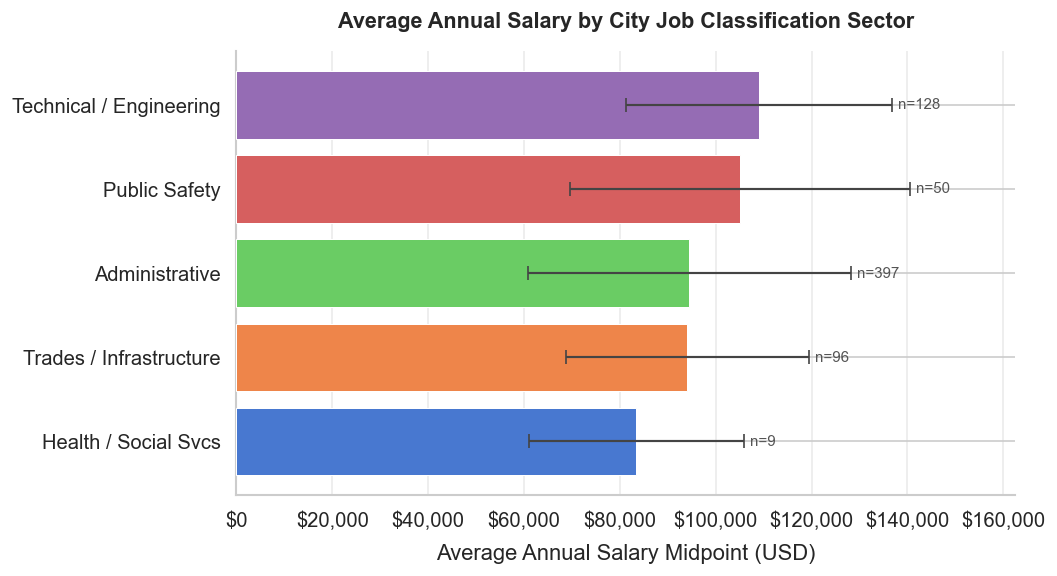

In [4]:
sector_stats = (
    df_valid.groupby("sector")["salary_mid"]
    .agg(mean="mean", std="std", count="count")
    .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(9, 5))

palette = sns.color_palette("muted", len(sector_stats))
ax.barh(
    sector_stats.index,
    sector_stats["mean"],
    xerr=sector_stats["std"],
    color=palette,
    edgecolor="white",
    linewidth=0.6,
    error_kw={"elinewidth": 1.3, "capsize": 4, "ecolor": "#444444"},
    zorder=3,
)

# n= annotations at end of error bar
for i, (idx, row) in enumerate(sector_stats.iterrows()):
    ax.text(
        row["mean"] + row["std"] + 1_200,
        i,
        f"n={int(row['count'])}",
        va="center",
        fontsize=9,
        color="#555555",
    )

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Average Annual Salary Midpoint (USD)", labelpad=8)
ax.set_ylabel("")
ax.set_title(
    "Average Annual Salary by City Job Classification Sector",
    fontweight="bold",
    pad=14,
    fontsize=13,
)
ax.set_xlim(0, sector_stats["mean"].max() + sector_stats["std"].max() + 18_000)
ax.grid(axis="x", alpha=0.4, zorder=0)

plt.tight_layout()
# plt.savefig("data_visualizations/...", dpi=150, bbox_inches="tight")
plt.show()

---
## Visualization 2 — Bar Chart

**Research Question:** Do higher formal education requirements in City of Los Angeles job bulletins consistently predict higher annual salaries across job classifications, or do credential requirements operate independently of compensation — functioning as access barriers rather than markers of valued expertise?

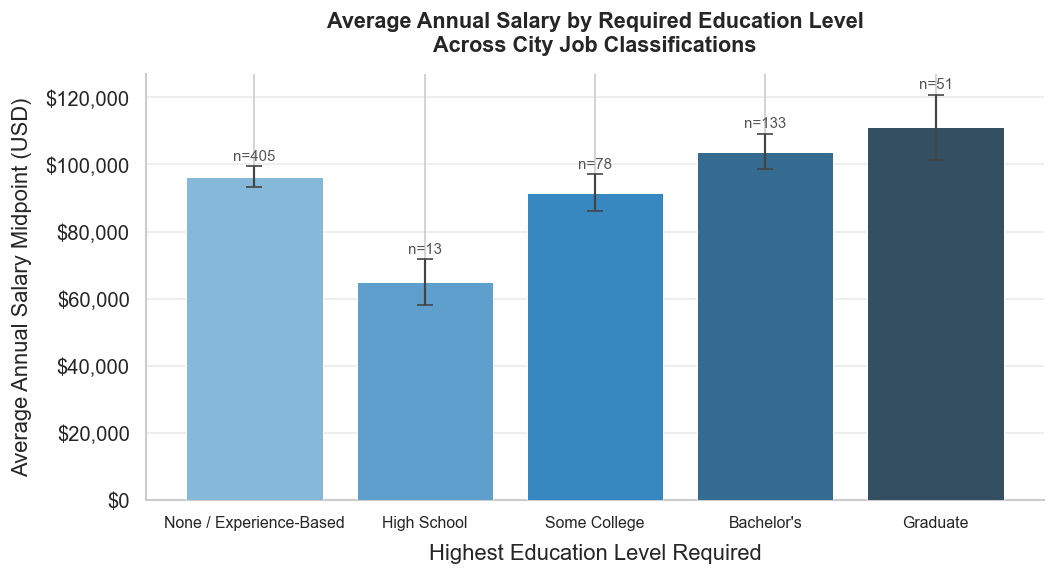

In [5]:
EDU_ORDER = [
    "None / Experience-Based",
    "High School",
    "Some College",
    "Bachelor's",
    "Graduate",
]

edu_present = [e for e in EDU_ORDER if e in df_valid["edu_level"].values]

edu_stats = (
    df_valid.groupby("edu_level")["salary_mid"]
    .agg(mean="mean", sem="sem", count="count")
    .reindex(edu_present)
)

# 95 % CI half-width
ci95 = edu_stats["sem"] * 1.96

fig, ax = plt.subplots(figsize=(9, 5))

palette = sns.color_palette("Blues_d", len(edu_present))
bars = ax.bar(
    edu_stats.index,
    edu_stats["mean"],
    yerr=ci95,
    color=palette,
    edgecolor="white",
    linewidth=0.6,
    error_kw={"elinewidth": 1.3, "capsize": 5, "ecolor": "#444444"},
    zorder=3,
)

# n= annotations above error bars
for bar, (idx, row), ci in zip(bars, edu_stats.iterrows(), ci95):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        row["mean"] + ci + 900,
        f"n={int(row['count'])}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#555555",
    )

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Highest Education Level Required", labelpad=8)
ax.set_ylabel("Average Annual Salary Midpoint (USD)", labelpad=8)
ax.set_title(
    "Average Annual Salary by Required Education Level\nAcross City Job Classifications",
    fontweight="bold",
    pad=14,
    fontsize=13,
)
ax.tick_params(axis="x", labelsize=9.5)
ax.grid(axis="y", alpha=0.4, zorder=0)

plt.tight_layout()
# plt.savefig("data_visualizations/...", dpi=150, bbox_inches="tight")
plt.show()

---
## Visualization 3 — Scatter Plot

**Research Question (new):** How does the minimum required years of work experience in City job bulletins relate to salary range midpoints across job classifications, and does accumulated work experience reliably translate into higher compensation — or do other structural factors disrupt that relationship?

Jobs with experience data: 612


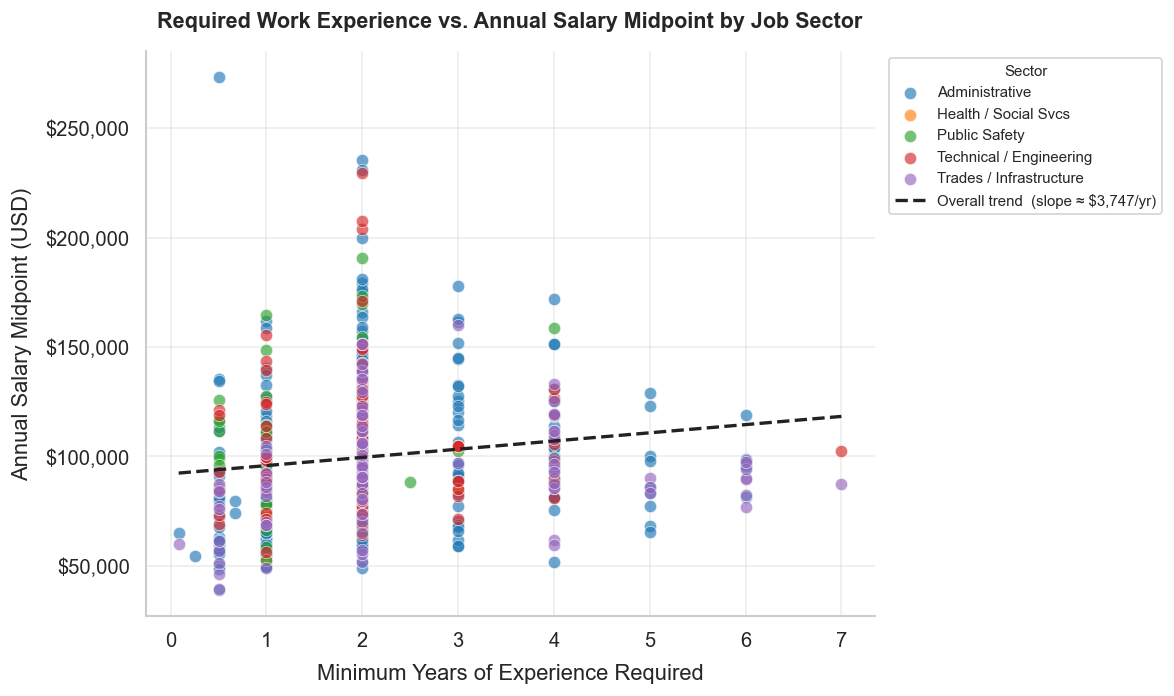

In [6]:
df_exp = df_valid.dropna(subset=["exp_years"]).copy()

sectors = sorted(df_exp["sector"].unique())
palette = dict(zip(sectors, sns.color_palette("tab10", len(sectors))))

fig, ax = plt.subplots(figsize=(10, 6))

for sector in sectors:
    grp = df_exp[df_exp["sector"] == sector]
    ax.scatter(
        grp["exp_years"],
        grp["salary_mid"],
        label=sector,
        color=palette[sector],
        alpha=0.65,
        s=55,
        edgecolors="white",
        linewidths=0.5,
        zorder=3,
    )

# Global OLS trend line
m, b = np.polyfit(df_exp["exp_years"], df_exp["salary_mid"], 1)
x_line = np.linspace(df_exp["exp_years"].min(), df_exp["exp_years"].max(), 300)
ax.plot(
    x_line,
    m * x_line + b,
    color="#222222",
    linewidth=2.0,
    linestyle="--",
    label=f"Overall trend  (slope ≈ ${m:,.0f}/yr)",
    zorder=4,
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Minimum Years of Experience Required", labelpad=8)
ax.set_ylabel("Annual Salary Midpoint (USD)", labelpad=8)
ax.set_title(
    "Required Work Experience vs. Annual Salary Midpoint by Job Sector",
    fontweight="bold",
    pad=14,
    fontsize=13,
)
ax.legend(
    title="Sector",
    framealpha=0.85,
    fontsize=9,
    title_fontsize=9,
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
)
ax.grid(alpha=0.35, zorder=0)

print(f"Jobs with experience data: {len(df_exp)}")
plt.tight_layout()
# plt.savefig("data_visualizations/...", dpi=150, bbox_inches="tight")
plt.show()

---
## Visualization 4 — Box Plot

**Research Question:** What does the distribution of salary ranges for internally-restricted (promotional) versus open-competitive City job classifications reveal about who the civil service structure rewards, and how does the internal mobility advantage vary across job sectors?

Sample counts per group:
sector                   exam_type       
Administrative           Open Competitive    232
                         Promotional         165
Health / Social Svcs     Open Competitive      8
                         Promotional           1
Public Safety            Open Competitive     21
                         Promotional          29
Technical / Engineering  Open Competitive     63
                         Promotional          65
Trades / Infrastructure  Open Competitive     45
                         Promotional          51


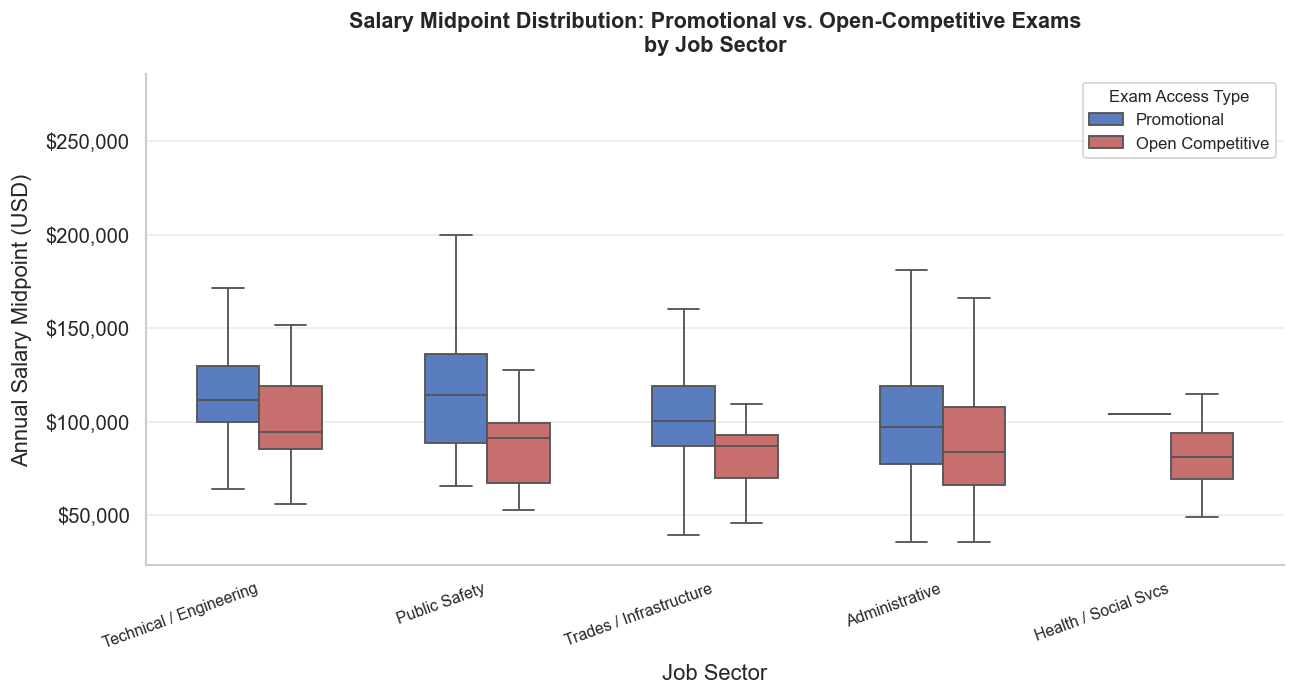

In [7]:
df_box = df_valid[
    df_valid["exam_type"].isin(["Promotional", "Open Competitive"])
].copy()

# Order sectors by median salary (descending) for readability
sector_order_box = (
    df_box.groupby("sector")["salary_mid"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=df_box,
    x="sector",
    y="salary_mid",
    hue="exam_type",
    order=sector_order_box,
    hue_order=["Promotional", "Open Competitive"],
    palette={"Promotional": "#4878CF", "Open Competitive": "#D65F5F"},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.45, "markeredgewidth": 0},
    width=0.55,
    linewidth=1.1,
    ax=ax,
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Job Sector", labelpad=8)
ax.set_ylabel("Annual Salary Midpoint (USD)", labelpad=8)
ax.set_title(
    "Salary Midpoint Distribution: Promotional vs. Open-Competitive Exams\nby Job Sector",
    fontweight="bold",
    pad=14,
    fontsize=13,
)
ax.legend(title="Exam Access Type", framealpha=0.85, fontsize=10, title_fontsize=10)
ax.tick_params(axis="x", labelsize=9.5)
plt.xticks(rotation=20, ha="right")
ax.grid(axis="y", alpha=0.4, zorder=0)

# Print counts per group for context
print("Sample counts per group:")
print(df_box.groupby(["sector", "exam_type"])["salary_mid"].count().to_string())

plt.tight_layout()
# plt.savefig("data_visualizations/...", dpi=150, bbox_inches="tight")
plt.show()